In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('../data/attrition_ml_ready.csv')

# Separate features and target
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Split train/test (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data split successfully!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set : {X_test.shape[0]} samples")
print("\nTarget Class Distribution in Test Set:")
print(y_test.value_counts(normalize=True))


Data split successfully!
Training set: 1176 samples
Testing set : 294 samples

Target Class Distribution in Test Set:
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


Now we are going to tackle the biggest challenge with HR datasets: Class Imbalance.

Since only about 16% of employees in our dataset actually left the company (Attrition = 1), a model could just predict "No" for everyone and still be 84% accurate! But that makes the model useless for HR, because it would miss all the people actually leaving.
To fix this, we will use a parameter called class_weight='balanced'. This tells the algorithms: "Hey, the 'Yes' class is rare, so if you predict it wrong, the penalty is much higher." It mathematically forces the model to pay attention to the minority class.

In [3]:
# Initialize models with class_weight='balanced'
lr_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
dt_balanced = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')
rf_balanced = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
# Train the models on the training data
lr_balanced.fit(X_train, y_train)
dt_balanced.fit(X_train, y_train)
rf_balanced.fit(X_train, y_train)

print("Models successfully trained with balanced class weights.")


Models successfully trained with balanced class weights.


In [4]:
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.4f}\n")

# Evaluate all three balanced models
evaluate_model(lr_balanced, "Logistic Regression (Balanced)")
evaluate_model(dt_balanced, "Decision Tree (Balanced)")
evaluate_model(rf_balanced, "Random Forest (Balanced)")


--- Logistic Regression (Balanced) ---
Accuracy : 0.7517
Precision: 0.3488
Recall   : 0.6383
F1-Score : 0.4511

--- Decision Tree (Balanced) ---
Accuracy : 0.7857
Precision: 0.3788
Recall   : 0.5319
F1-Score : 0.4425

--- Random Forest (Balanced) ---
Accuracy : 0.8435
Precision: 0.5200
Recall   : 0.2766
F1-Score : 0.3611



In [5]:
# Set up the parameter grid we want to explore
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}

print("Starting Grid Search... this might take a minute.")

# Initialize GridSearchCV optimizing specifically for RECALL
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    scoring='recall',   # Focus entirely on catching the "Yes" class
    cv=5,               # 5-fold cross validation
    n_jobs=-1           # Use all computer processors to speed it up
)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Extract the absolute best model
best_rf = grid_search.best_estimator_
print(f"Best Parameters found: {grid_search.best_params_}")


Starting Grid Search... this might take a minute.
Best Parameters found: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}


--- Random Forest (Tuned for Recall) ---
Accuracy : 0.7891
Precision: 0.4000
Recall   : 0.6383
F1-Score : 0.4918



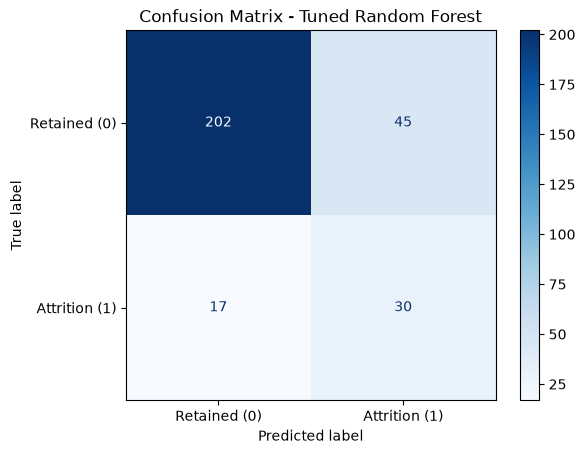

In [6]:
# Evaluate the tuned model
evaluate_model(best_rf, "Random Forest (Tuned for Recall)")

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test, y_test, 
    display_labels=['Retained (0)', 'Attrition (1)'],
    cmap=plt.cm.Blues
)
disp.ax_.set_title("Confusion Matrix - Tuned Random Forest")
plt.show()


--- ROC Curve ---


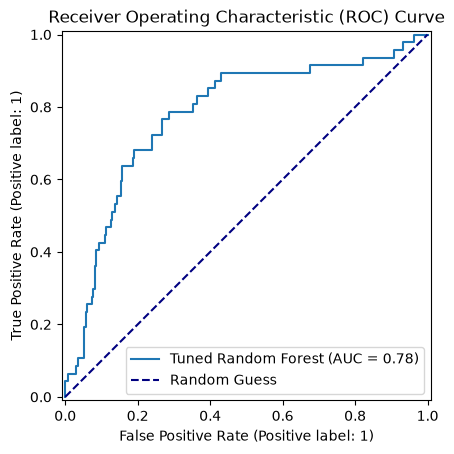

In [7]:
# Plot ROC Curve
print("--- ROC Curve ---")
disp_roc = RocCurveDisplay.from_estimator(
    best_rf, X_test, y_test,
    name='Tuned Random Forest'
)
disp_roc.ax_.set_title("Receiver Operating Characteristic (ROC) Curve")

# Add a diagonal line for a "random guess" baseline
plt.plot([0, 1], [0, 1], linestyle='--', color='navy', label='Random Guess')
plt.legend()
plt.show()



In [8]:
# Save the absolute best optimized model
final_model_path = '../models/final_optimized_rf_model.pkl'

joblib.dump(best_rf, final_model_path)
print(f"Success! Final optimized model saved to: {final_model_path}")


Success! Final optimized model saved to: ../models/final_optimized_rf_model.pkl
